In [ ]:
!nvidia-smi

Tue May 23 13:24:28 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   65C    P8    11W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
# # Intstall library and softwares
!pip install transformers datasets sacremoses &> /dev/null
!pip install timm &> /dev/null
!apt install poppler-utils &> /dev/null
!pip install pdf2image tqdm &> /dev/null
# !pip install easyocr &> /dev/null
!pip install opencv-python==4.5.5.64 > /dev/null
# !pip install paddlepaddle-gpu
!pip install img2table[paddle] > /dev/null

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 2.11.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 3.20.0 which is incompatible.
google-cloud-bigquery 3.9.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 3.20.0 which is incompatible.
google-cloud-bigquery-storage 2.19.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 3.20.0 which is incompatible.
google-cloud-datastore 2.15.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 3.20.0 which is incompatible.
google-cloud-firestore 2.11.0 requires protobuf!=3.20.0,!=3.20.

There are several fine tuned huggingface models to detect tables from images. There are a list of them
1. TahaDouaji/detr-doc-table-detection
2. Benito/DeTr-TableDetection-5000-images


In [ ]:
from pdf2image import convert_from_path
import torch
import numpy as np
from transformers import AutoImageProcessor, AutoModelForObjectDetection
import PIL

def load_model():
  preprocessor_url = "microsoft/table-transformer-detection"
  image_processor = AutoImageProcessor.from_pretrained(preprocessor_url)
  model_url = 'Benito/DeTr-TableDetection-5000-images'
  model = AutoModelForObjectDetection.from_pretrained(model_url)
  return image_processor, model

def convert_pdf_to_img(url):
  images = convert_from_path(url)
  return images

def detect_tables(images, model, preprocessor):
  inputs = preprocessor(images=images, return_tensors="pt")
  outputs = model(**inputs)
  target_sizes = torch.tensor( [img.size[::-1] for img in images])
  results = preprocessor.post_process_object_detection(outputs, threshold=0.6, target_sizes=target_sizes)
  for i in  range(len(results)):
    pageResult = results[i]
    for score, label, box in zip(pageResult["scores"], pageResult["labels"], pageResult["boxes"]):
        box = [round(i, 2) for i in box.tolist()]
        print(
            f"Page No {i+1} Detected {model.config.id2label[label.item()]} with confidence "
            f"{round(score.item(), 3)} at location {box}"
        )
  return results

def apply_results_on_images(images, results):
  extractedTables = []
  for i in range(len(results)):
    for box in results[i]['boxes']:
      obj = {
          'index': i,
          'img': images[i]
      }
      obj['extracted'] = PIL.Image.fromarray(np.array(images[i])[int(box[1]):int(box[3]), int(box[0]):int(box[2])])
      obj['box'] = ( (int(box[0]), int(box[1])), (int(box[2]), int(box[3])) )
      extractedTables.append(obj)
  return extractedTables

In [ ]:
preprocessor, model = load_model()

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


In [ ]:
# pdf_path = '/content/Income Statement Sample Asset ABC.pdf'
pdf_path = '/content/Rent Roll Sample Asset 789.pdf'
# pdf_path = '/content/Rent Roll Sample Asset 123.pdf'
test_images = convert_pdf_to_img(pdf_path)
results = detect_tables(test_images, model, preprocessor)
extracted_tables = apply_results_on_images(test_images, results)

Page No 1 Detected table with confidence 0.899 at location [45.6, 230.25, 2141.52, 727.11]
Page No 1 Detected table with confidence 0.782 at location [61.52, 747.0, 723.76, 1179.93]


In [ ]:
def draw_rows_and_cols(extraction, rowcolor='red', colcolor='blue', width=2):
    image = extraction['extracted']
    draw = PIL.ImageDraw.Draw(image)
    for bound in extraction['rows']: # iterate though all the tuples of output
        x1,y1,x2,y2 = bound[0]
        p0, p1, p2, p3 = (x1,y1), (x1,y2), (x2,y2), (x2,y1) # get coordinates
        draw.line([*p0, *p1, *p2, *p3, *p0], fill=rowcolor, width=width)
    for bound in extraction['cols']: # iterate though all the tuples of output
        x1,y1,x2,y2 = bound[0]
        p0, p1, p2, p3 = (x1,y1), (x1,y2), (x2,y2), (x2,y1) # get coordinates
        draw.line([*p0, *p1, *p2, *p3, *p0], fill=colcolor, width=width)
    return image

In [ ]:
easyOCR = None
paddleOCR = None
def perform_ocr(result, ocr='paddle'):
  img = result['extracted']
  bounds = []
  if ocr == 'easyocr':
    global easyOCR
    if easyOCR == None:
      import easyocr
      easyOCR = easyocr.Reader(['en'])
    bounds = easyOCR.readtext(np.array(img), detail=1)
  else:
    global paddleOCR
    if paddleOCR == None:
      from img2table.ocr import PaddleOCR
      paddleOCR = PaddleOCR(lang="en")
    bounds = paddleOCR.hocr(np.array(img))
    bounds = [ (b[0], *b[1]) for b in bounds ]
  result['extract_bounds'] = bounds;
  result['img_bounds'] = get_full_image_bounds(result, bounds)
  return result

def get_full_image_bound(result, bound):
  new_box = []
  for i in range(len(bound[0])):
    p = [bound[0][i][0] + result['box'][0][0], bound[0][i][1] + result['box'][0][1]]
    new_box.append(p)
  return (new_box, bound[1], bound[2])

def get_full_image_bounds(result, bounds):
  full_image_bounds = []
  for bound in bounds:
    full_image_bounds.append(get_full_image_bound(result, bound))
  return full_image_bounds

def draw_boxes(image, bounds, color='yellow', width=2):
    draw = PIL.ImageDraw.Draw(image)
    for bound in bounds: # iterate though all the tuples of output
        p0, p1, p2, p3 = bound[0] # get coordinates
        draw.line([*p0, *p1, *p2, *p3, *p0], fill=color, width=width)
    return image

In [ ]:
result = perform_ocr(extracted_tables[0], 'paddle')
img = draw_boxes(result['img'], result['img_bounds'], 'red')

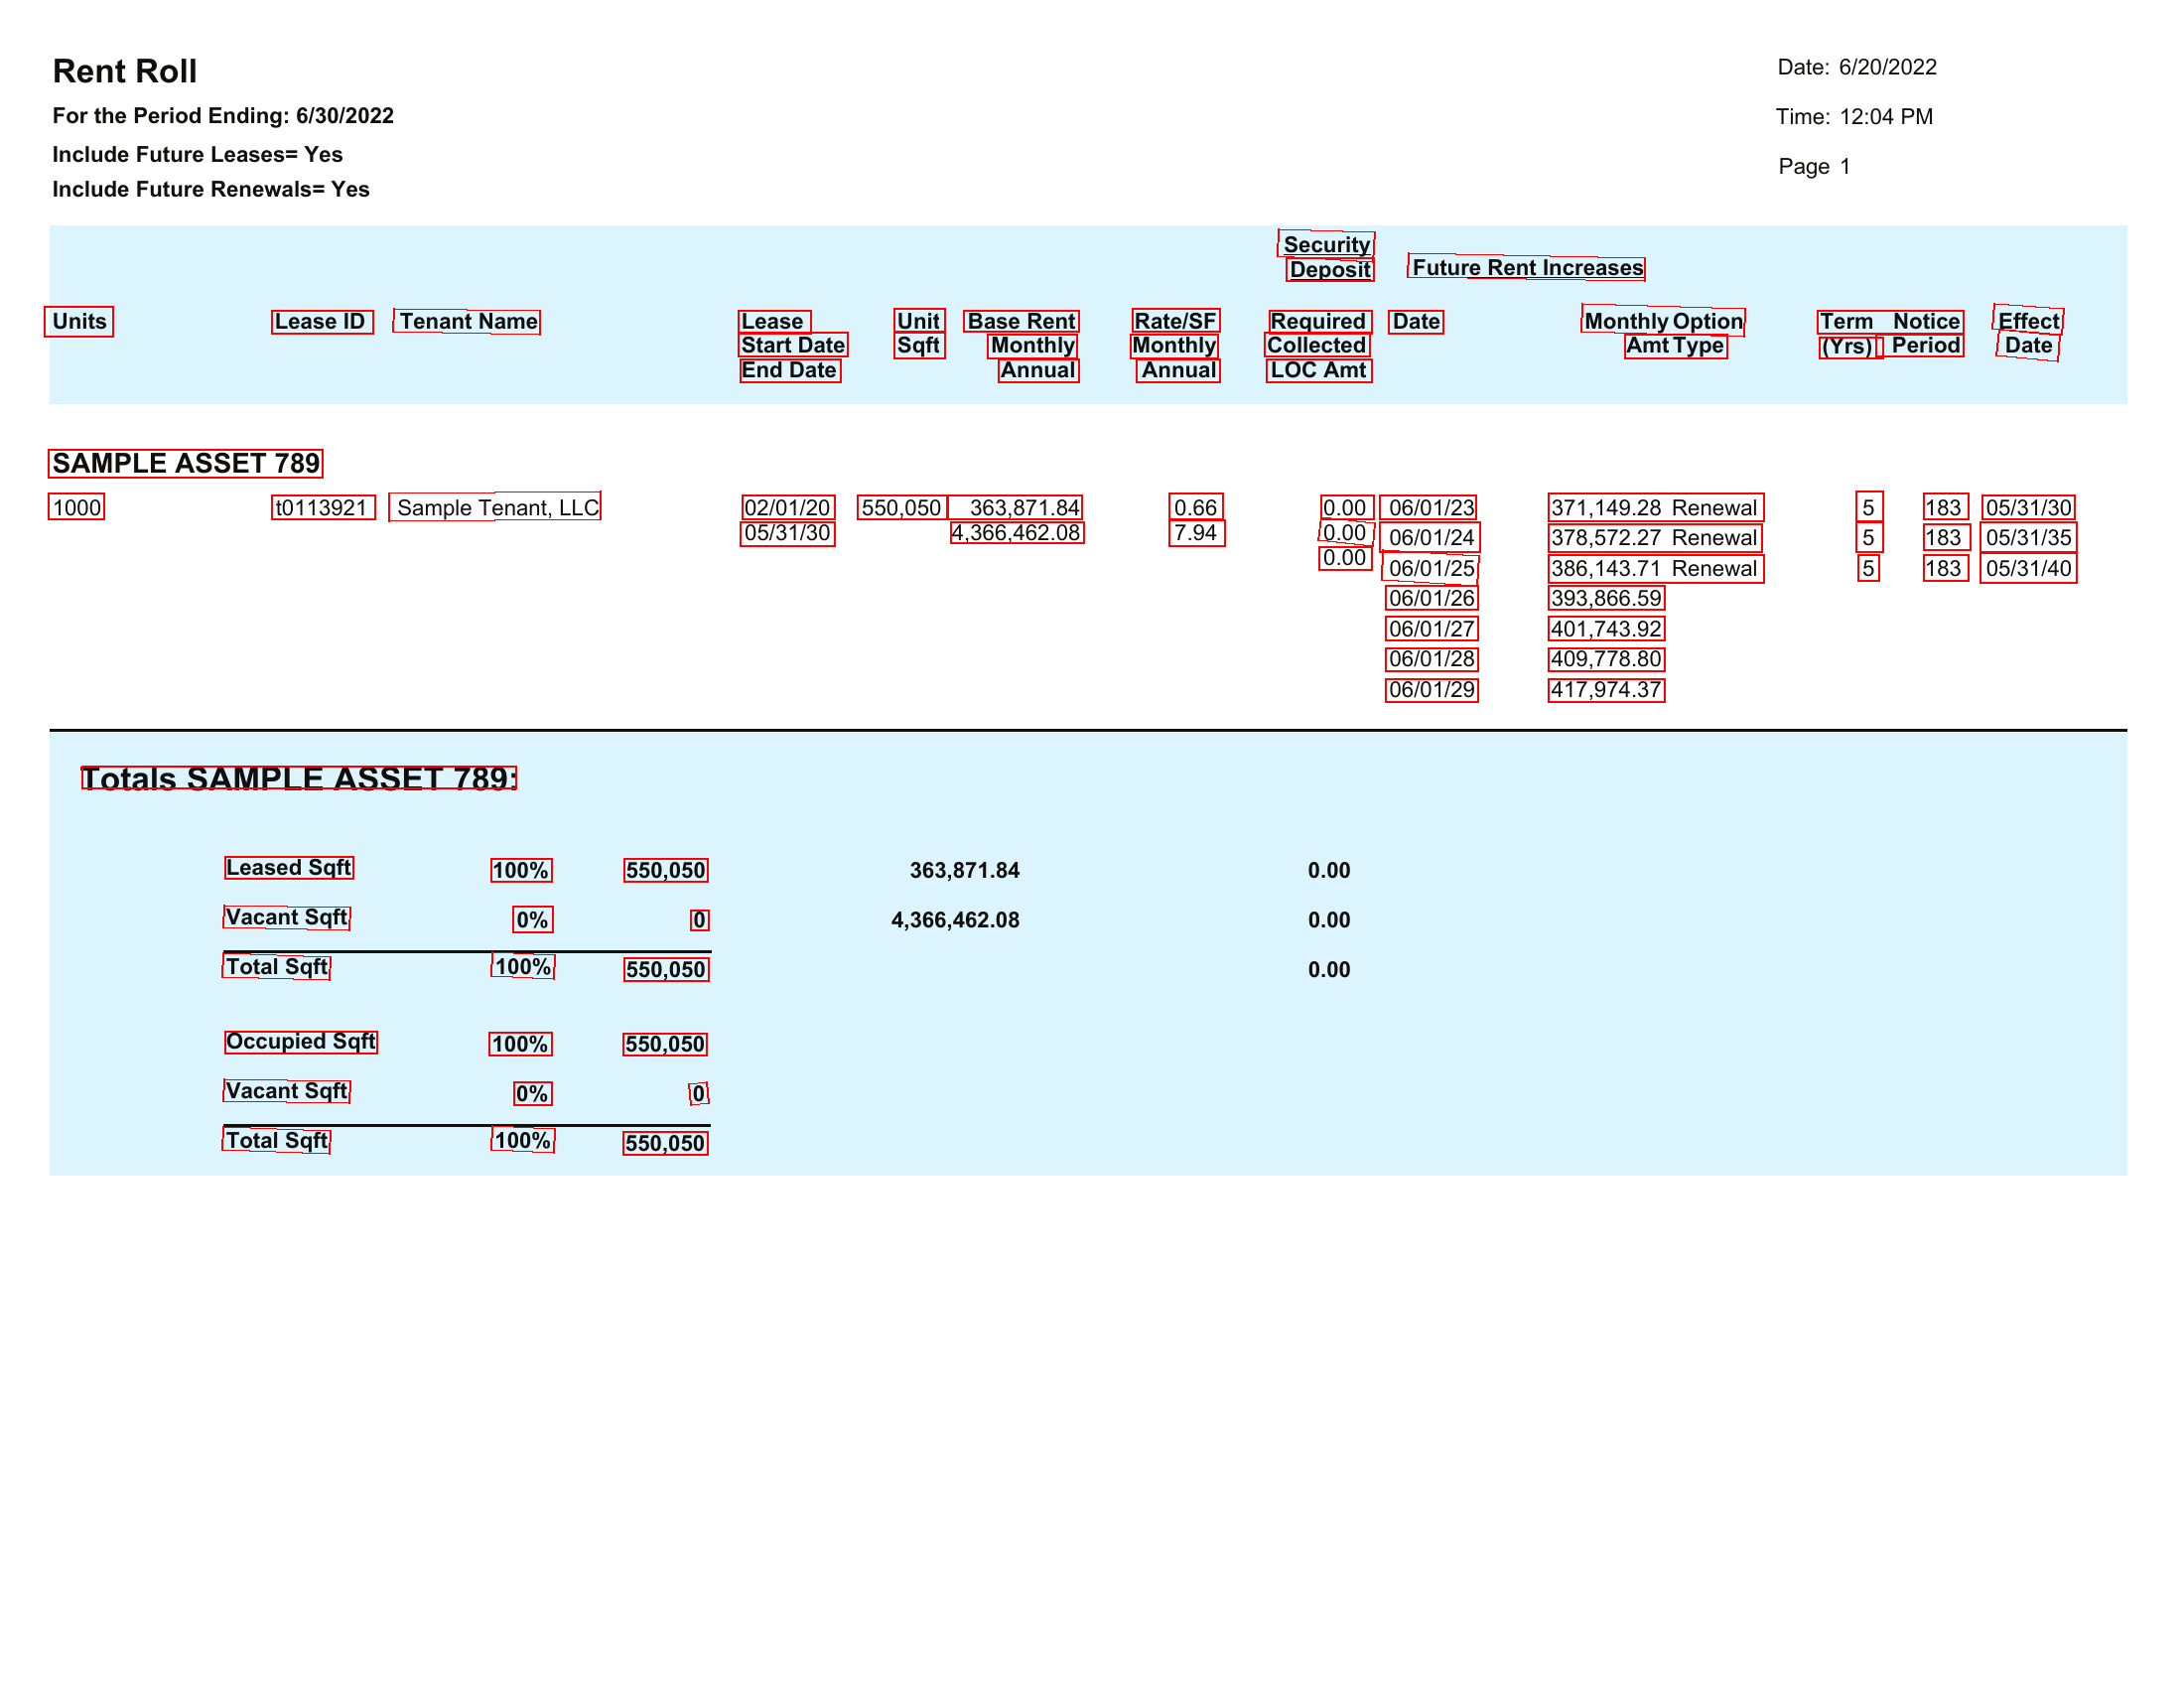

In [ ]:
img

In [ ]:
"""
    Algorithm:
    1. Identify the table bounds ( Top and Bottom ) on the extracted table
    2. Using the Top and Bottom bound, count the ocr elements and try to detect potential columns
    3. Detect the alignment of the each column
    4. As per the alignment of the column, draw the lines
"""

def detect_rows(bounds, size):
    cols = {}
    rows = {}
    for bound in bounds:
        p0, p1, p2, p3 = bound[0]
        row_height = p2[1] - p0[1]
        row_mid = (p0[1] + p2[1])//2
        for mid in rows:
          r1, r2 = rows[mid]['span']
          if row_mid > r1 and row_mid < r2:
              row_mid = mid
        try:
            rows[row_mid]['count'] += 1
            rows[row_mid]['ocr'].append(bound)
            if rows[row_mid]['span'][0] > p0[1]:
                rows[row_mid]['span'][0] = p0[1]
            if rows[row_mid]['span'][1] < p2[1]:
                rows[row_mid]['span'][1] = p2[1]
            rows[row_mid]['height'] = rows[row_mid]['span'][1] - rows[row_mid]['span'][0]
        except Exception as e:
            rows[row_mid] = { 'count': 1, 'span': [p0[1], p2[1]], 'height': row_height, 'ocr': [bound] }

    max_row_val_count = 0
    avg_row_val_count = 0
    for row in rows:
        l = rows[row]['count']
        if l > max_row_val_count:
            max_row_val_count = l
        avg_row_val_count += l
    avg_row_val_count = avg_row_val_count // len(rows)

    tolerance = avg_row_val_count * 0.75
    final_rows = {**rows}
    for row in rows:
        if rows[row]['count'] < tolerance:
            del(final_rows[row])

    temp_rows = final_rows
    tableTop = size[1];
    tableBottom = 0;
    rowLines = []
    rowMidLines = [mid for mid in temp_rows]
    rowMidLines.sort()
    for i in range(len(rowMidLines) - 1):
      mid, nextMid = rowMidLines[i], rowMidLines[i+1]
      # rowLines.append( (rows[mid]['span'][1] + rows[nextMid]['span'][0])/2 )
      rowLines.append(rows[mid]['span'][0])
      rowLines.append(rows[nextMid]['span'][0])

      if tableTop > rows[mid]['span'][0]:
        tableTop = rows[mid]['span'][0]
      if tableBottom < rows[nextMid]['span'][1]:
        tableBottom = rows[nextMid]['span'][1]

    return (final_rows, rowLines, (tableTop, tableBottom))


def detect_cols(bounds, horizontal_bound):
    cols = {}
    for bound in bounds[::-1]:
        p0, p1, p2, p3 = bound[0]
        if p1[1] < horizontal_bound[0] or p2[1] > horizontal_bound[1]:
          # print(p1[1] , horizontal_bound[0], p2[1] , horizontal_bound[1])
          continue
        col_width = p2[0] - p0[0]
        col_mid = (p0[0] + p2[0])//2
        actual_mid = col_mid
        for mid in cols:
            r1, r2 = cols[mid]['span']
            if col_mid > r1 and col_mid < r2:
                col_mid = mid
        try:
            cols[col_mid]['count'] += 1
            cols[col_mid]['left'] += p0[0]
            cols[col_mid]['right'] += p2[0]
            cols[col_mid]['mid'] += actual_mid
            if cols[col_mid]['span'][0] > p0[0]:
                cols[col_mid]['span'][0] = p0[0]
            if cols[col_mid]['span'][1] < p2[0]:
                cols[col_mid]['span'][1] = p2[0]
            cols[col_mid]['width'] = cols[col_mid]['span'][1] - cols[col_mid]['span'][0]
        except:
            cols[col_mid] = { 'width': col_width, 'span': [p0[0], p2[0]], 'count': 1, 'mid': actual_mid, 'left': p0[0], 'right': p2[0] }

    temp_cols = {**cols}

    max_col_val_count = 0
    avg_col_val_count = 0
    for col in cols:
        l = cols[col]['count']
        if l > max_col_val_count:
            max_col_val_count = l
        avg_col_val_count += l
    avg_col_val_count = avg_col_val_count // len(cols)
    # print(max_col_val_count, avg_col_val_count)
    final_cols = {**cols}
    tolerance = avg_col_val_count * 0.75
    for col in cols:
        if cols[col]['count'] < tolerance:
            del(final_cols[col])

    cols = final_cols

    # detect alignment
    for mid in cols:
        avg_mid, avgLeft, avgRight = cols[mid]['mid'] // cols[mid]['count'], cols[mid]['left'] // cols[mid]['count'], cols[mid]['right'] // cols[mid]['count']
        leftSpan, rightSpan = cols[mid]['span']
        tolerance = cols[mid]['width'] * 0.1
        if abs(avgLeft - leftSpan) <= tolerance:
            cols[mid]['alignment'] = 'left'
        elif abs(avgRight - rightSpan) <= tolerance:
            cols[mid]['alignment'] = 'right'
        else:
            cols[mid]['alignment'] = 'mid'
        if cols[mid]['alignment'] == 'mid':
            # print(avgLeft, avgRight, leftSpan, rightSpan, tolerance)
            pass

    colLines = []
    colMidPos = [mid for mid in cols]
    colMidPos.sort()
    for i in range(len(colMidPos) - 1):
        mid, nextMid = colMidPos[i], colMidPos[i+1]
        # colLines.append( (cols[mid]['span'][1] + cols[nextMid]['span'][0])/2 )
        colLines.append( cols[mid]['span'][1] )
        colLines.append( cols[nextMid]['span'][0] )

    return (cols, colLines)



def detect_row_col_boundary(bounds, img):
  rows = detect_rows(bounds, img.size)
  cols = detect_cols(bounds, rows[2])

  colLines = [0, *cols[1], img.size[0]]
  colBoxes = []
  for i in range(len(colLines)-1):
    x1, x2 = colLines[i], colLines[i+1]
    colBoxes.append([[x1, rows[2][0], x2, img.size[1]], 1])

  rowLines = [rows[2][0], *rows[1], rows[2][1]]
  rowBoxes = []
  for i in range(len(rowLines)-1):
    y1, y2 = rowLines[i], rowLines[i+1]
    if abs(y2 - y1) > 0 :
      rowBoxes.append([[0, y1, img.size[0], y2], 1])
  return rowBoxes, colBoxes




In [ ]:
result['rows'], result['cols'] = detect_row_col_boundary(result['extract_bounds'], result['extracted'])
# result['cols'] = []

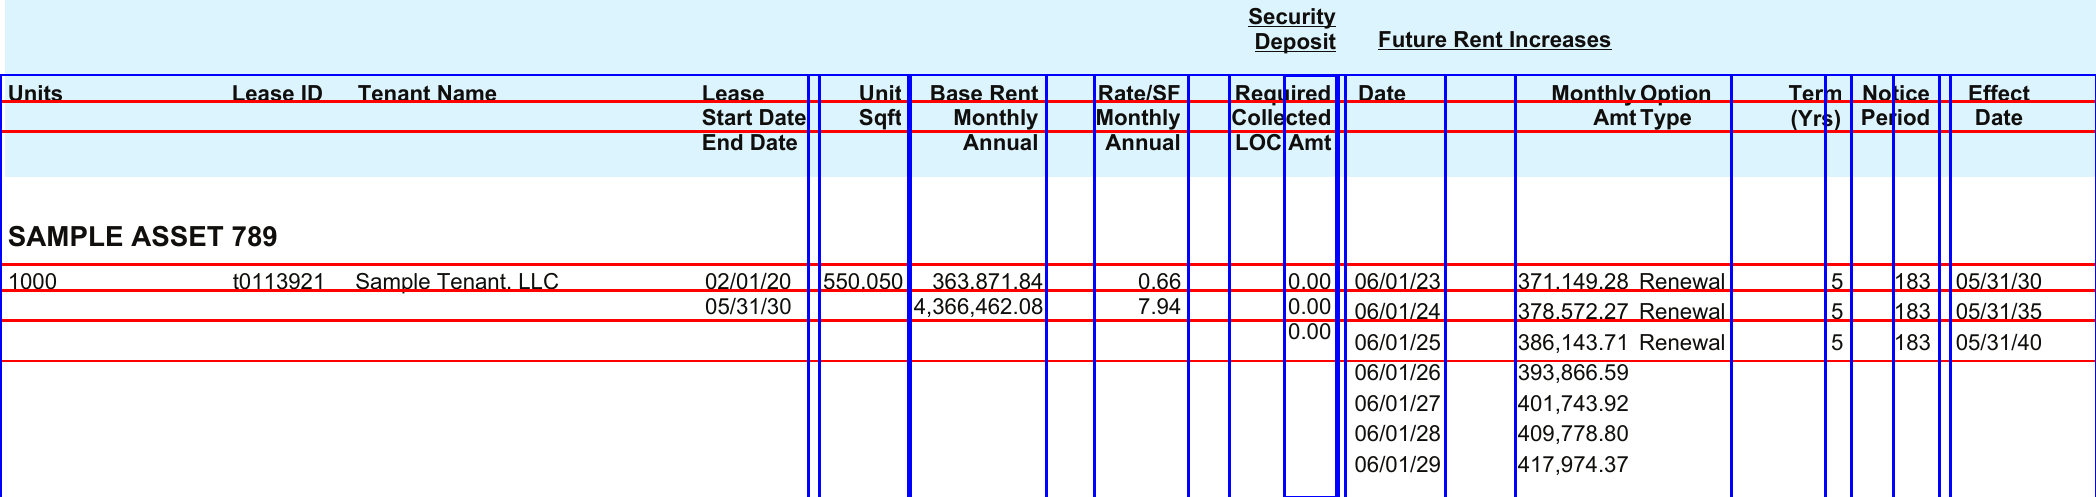

In [ ]:
draw_rows_and_cols(result, colcolor='blue', rowcolor="red")

In [ ]:
def get_table_structure_detector(data):
  rowLinePos = [*[r[0][1] for r in data['rows']], data['rows'][-1][0][3]]
  colLinePos = [data['cols'][0][0][0], *[c[0][2] for c in data['cols']]]
  table = [ [ '' for j in range(len(colLinePos)-1) ] for i in range(len(rowLinePos)-1) ]
  table_structure = []


  for bound in data['extract_bounds']:
    p0, p1, p2, p3 = bound[0]
    if p0[0] < colLinePos[0] or p0[0] > colLinePos[-1] or p0[1] < rowLinePos[0] or p0[1] > rowLinePos[-1]:
      continue
    rowStart, rowEnd = -1, -1
    colStart, colEnd = -1, -1
    for i in range(len(rowLinePos)-1):
      if p0[1] < rowLinePos[i+1]:
        rowStart = i;
        break
    for i in range(len(colLinePos)-1):
      if p0[0] < colLinePos[i+1]:
        colStart = i;
        break
    if bound[1] == "Statement (12 months)":
      print(bound, rowStart, colStart)
    table[rowStart][colStart] += bound[1]

  # Remove blank cols
  blankCols = {}
  for i in range(len(colLinePos)-1):
    isBlank = True
    for r in table:
      if r[i] != '':
        isBlank = False
        break
    blankCols[i] = isBlank
  print(rowLinePos)
  print(colLinePos)
  print(blankCols)
  final_table = []
  for r in table:
    newR = []
    for i in range(len(r)):
      if not blankCols[i]:
        newR.append(r[i])
    final_table.append(newR)

  return final_table


In [ ]:
table = get_table_structure_detector(result)
tableDict = { f'col{cI}' for cI in range(len(table[0])) }

[122.0, 332.0, 361.0, 396.0, 457.0, 486.0, 515.0, 547.0, 582.0, 608.0, 641.0, 669.0, 704.0, 730.0, 766.0, 797.0, 881.0, 911.0, 943.0, 981.0, 1010.0, 1042.0, 1071.0, 1103.0, 1126.0, 1164.0, 1187.0, 1225.0, 1251.0, 1280.0, 1318.0, 1348.0]
[0, 366.0, 494.0, 621.0, 647.0, 774.0, 800.0, 930.0, 959.0, 1086.0, 1107.0, 1239.0, 1268.0, 1395.0, 1421.0, 1548.0, 1574.0, 1704.0, 1730.0, 1860.0, 1886.0, 2013.0, 2037.0, 2167.0, 2193.0, 2323.0, 2349.0, 2494]
{0: False, 1: True, 2: False, 3: True, 4: False, 5: True, 6: False, 7: True, 8: False, 9: True, 10: False, 11: True, 12: False, 13: True, 14: False, 15: True, 16: False, 17: True, 18: False, 19: True, 20: False, 21: True, 22: False, 23: True, 24: False, 25: True, 26: False}


In [ ]:

import csv

with open('/content/output_3.csv', 'w', encoding='UTF8') as f:
    writer = csv.writer(f)
    # write the header
    # writer.writerow(h)
    for r in table:
        writer.writerow(r)

In [ ]:
from transformers import TapasConfig, TFTapasForQuestionAnswering, TapasTokenizer
def load_table_qa_model():
  config_url = "google/tapas-base-finetuned-wtq"
  config = TapasConfig(config_url)

  tokenizer = TapasTokenizer.from_pretrained(model_name)

  model_url = "google/tapas-base"
  model = TFTapasForQuestionAnswering.from_pretrained(model_url, config=config)
  return model

[['',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  'Statement (12 months)',
  'Period = Jul 2021-Jun 2022',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  ''],
 [' Potential Rent',
  '',
  'Jul 2021',
  '',
  'Aug 2021',
  '',
  'Sep 2021',
  '',
  'Oct 2021',
  '',
  'Nov 2021',
  '',
  'Dec 2021',
  '',
  'Jan 2022',
  '',
  'Feb 2022',
  '',
  'Mar 2022',
  '',
  'Apr 2022',
  '',
  'May 2022',
  '',
  ' Jun 2022',
  '',
  'Total'],
 ['',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  ''],
 ['Residential GPR Gross Potential Rent',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '544,010.00',
  '',
  '6,528,120.00'],
 ['',
  '',
  ''

In [ ]:
import json

# Opening JSON file
f = open('/content/c3.json')

# returns JSON object as
# a dictionary
data = json.load(f)
dataMap = {}
blockTypes = set(['CELL', 'KEY_VALUE_SET', 'LINE', 'PAGE', 'TABLE', 'TABLE_TITLE', 'WORD'])
dataIndexed = { key: {} for key in blockTypes }
for block in data["Blocks"]:
  dataMap[block['Id']] = block
  blockTypes.add(block['BlockType'])
  # dataIndexed[block['BlockType']].append(block['Id'])
  dataIndexed[block['BlockType']][block['Id']] = True


In [ ]:
blockId = data["Blocks"][0]['Relationships'][0]['Ids'][0]
blockId = dataMap[blockId]['Relationships'][0]['Ids'][0]
dataMap[blockId]

{'BlockType': 'WORD',
 'Confidence': 38.68247604370117,
 'Geometry': {'BoundingBox': {'Height': 0.04338442161679268,
   'Left': 0.5172485709190369,
   'Top': 0.0939411073923111,
   'Width': 0.22760777175426483},
  'Polygon': [{'X': 0.5172485709190369, 'Y': 0.09409777075052261},
   {'X': 0.7448263168334961, 'Y': 0.0939411073923111},
   {'X': 0.7448563575744629, 'Y': 0.13717059791088104},
   {'X': 0.5172768235206604, 'Y': 0.13732552528381348}]},
 'Id': 'e8e53bc6-a50c-41c2-a2c1-f9d822409c91',
 'Page': 1,
 'Text': 'Platinum Equity',
 'TextType': 'PRINTED'}

In [ ]:
table = dataMap[list(dataIndexed['TABLE'].keys())[0]]
cell = dataMap[table['Relationships'][0]['Ids'][0]]
dataMap[cell['Relationships'][0]['Ids'][0]]

table_title = dataMap[list(dataIndexed['TABLE_TITLE'].keys())[0]]
[dataMap[id]['Text'] for id in table_title['Relationships'][0]['Ids']]

['Total',
 'Amount',
 'Due:',
 'Your',
 'total',
 'amount',
 'due',
 'in',
 'connection',
 'with',
 'the',
 'investments',
 'described',
 'above',
 'is',
 'as',
 'follows:']

In [ ]:
for tableId in dataIndexed['TABLE'].keys():
  table = dataMap[tableId]
  for cellId in table['Relationships'][0]['Ids']:
    cell = dataMap[cellId]
    try:
      for lineId in cell['Relationships'][0]['Ids']:
        line = dataMap[lineId]
        dataIndexed[line['BlockType']][lineId] = False
    except:
      pass


In [ ]:
words = []
for id in dataIndexed['WORD']:
  if dataIndexed['WORD'][id]:
    words.append(id)


In [ ]:
for id in words:
  print(dataMap[id]['Text'])
dataIndexed['WORD']